In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
assets = pd.read_csv("C:/Users/Mridul/OneDrive/Desktop/Liquidity Risk Project/data/assets.csv")
liabilities = pd.read_csv("C:/Users/Mridul/OneDrive/Desktop/Liquidity Risk Project/data/liabilities.csv")

print(assets)
print(liabilities)

             Asset  Market_Value  Category  Haircut  Maturity_Days  RSF_Factor
0       Govt Bonds      50000000     HQLA1     0.00              1        0.05
1  Corporate Bonds      10000000     HQLA2     0.15              7        0.15
2         Equities      20000000   NonHQLA     0.40             30        0.50
3            Loans      40000000  Illiquid     0.50             90        0.85
              Liability    Amount  Maturity_Days  ASF_Factor
0       Retail Deposits  40000000              1         0.9
1     Wholesale Funding  30000000              7         0.5
2  Short Term Borrowing  20000000             30         0.0
3        Long Term Debt  25000000            365         1.0


In [3]:
#Calculate HQLA

In [4]:
assets["HQLA_value"] = assets["Market_Value"] * (1- assets["Haircut"])
assets['HQLA_value']

0    50000000.0
1     8500000.0
2    12000000.0
3    20000000.0
Name: HQLA_value, dtype: float64

In [5]:
HQLA = assets.loc[assets["Category"].isin(["HQLA1", "HQLA2"]), "HQLA_value"].sum()
HQLA

np.float64(58500000.0)

In [6]:
#Calculate Net Outflow

In [7]:
short_term = liabilities[liabilities["Maturity_Days"] <= 30]
net_outflow = short_term["Amount"].sum() * 0.25
print(net_outflow)

22500000.0


In [8]:
# Calculate LCR (Liquidity Coverage Ratio = HQLA/ Net outflow)

In [9]:
LCR = HQLA/net_outflow
print("Liquidity Coverage Ratio:", LCR.round(2))

if LCR <1 :
    print("Below Basel Requirement.")
else:
    print("Meet Basel Requirement.")

Liquidity Coverage Ratio: 2.6
Meet Basel Requirement.


In [10]:
liabilities["ASF"] = liabilities["Amount"] * liabilities["ASF_Factor"]
ASF_total = liabilities["ASF"].sum()
ASF_total

np.float64(76000000.0)

In [11]:
assets["RSF"] = assets["Market_Value"]* assets["RSF_Factor"]
RSF_total = assets["RSF"].sum()
RSF_total

np.float64(48000000.0)

In [12]:
# Net Stable Funding Ratio(NSFR) = Available Stable Funding(ASF)/ Required Stable Funding(RSF)

In [13]:
NSFR = ASF_total/ RSF_total
print("Net Stable Funding Ratio:", NSFR.round(2))

if NSFR < 1:
    print("Insufficient Stable Funding.")
else:
    print("Meet Basel Requirement.")

Net Stable Funding Ratio: 1.58
Meet Basel Requirement.


In [14]:
# Cash Flow Mismatch by Maturity Bucket

In [20]:
def bucket(days):
    if days <=1:
        return "1 Day"
    elif days <=7:
        return "7 Days"
    elif days<=30:
        return "30 Days"
    else:
        return"90+ Days"

assets['bucket'] = assets["Maturity_Days"].apply(bucket)
liabilities['bucket'] = liabilities["Maturity_Days"].apply(bucket)

assets['bucket']
liabilities['bucket']

0       1 Day
1      7 Days
2     30 Days
3    90+ Days
Name: bucket, dtype: object

In [21]:
inflow = assets.groupby('bucket')["Market_Value"].sum()
outflow = liabilities.groupby("bucket")["Amount"].sum()

gap = inflow-outflow
print(gap)

bucket
1 Day       10000000
30 Days            0
7 Days     -20000000
90+ Days    15000000
dtype: int64


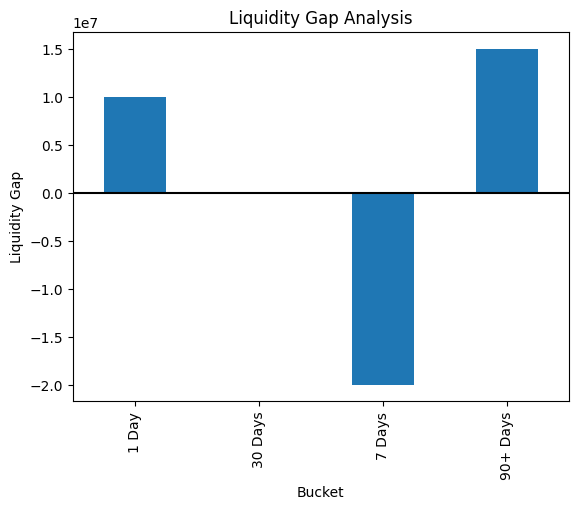

In [22]:
gap.plot(kind= 'bar')
plt.axhline(0, color= "black")
plt.title("Liquidity Gap Analysis")
plt.xlabel("Bucket")
plt.ylabel("Liquidity Gap")
plt.show()

In [23]:
#Stress Scenario Analysis
#Assumptions.
# 1. 30% Deposit Withdrawal i.e ouflow will increase
# 2. Equity Value Drop 40%
# 3. Corporate Bond Haircut Increase

In [24]:
stress_assets = assets.copy()
stress_liabilities = liabilities.copy()

In [25]:
stress_assets.loc[stress_assets["Asset"]== "Equities",
    "Market_Value"
    ]* (1-0.40)

2    12000000.0
Name: Market_Value, dtype: float64

In [26]:
stress_liabilities.loc[stress_liabilities["Liability"] == "Retail Deposits",
    "Amount"
    ]*=1.30
print(stress_liabilities)

              Liability    Amount  Maturity_Days  ASF_Factor         ASF  \
0       Retail Deposits  52000000              1         0.9  36000000.0   
1     Wholesale Funding  30000000              7         0.5  15000000.0   
2  Short Term Borrowing  20000000             30         0.0         0.0   
3        Long Term Debt  25000000            365         1.0  25000000.0   

     bucket  
0     1 Day  
1    7 Days  
2   30 Days  
3  90+ Days  


In [27]:
stress_assets.loc[stress_assets["Asset"] == "Corporate Bonds", "Haircut"] += 0.10
stress_assets["stress_HQLA_value"] = stress_assets["Market_Value"] * (1 - stress_assets["Haircut"])

stress_HQLA = stress_assets.loc[stress_assets["Category"].isin(["HQLA1", "HQLA2"]), 'stress_HQLA_value'].sum()


In [28]:
stress_short_term = stress_liabilities[liabilities["Maturity_Days"] <= 30]
stress_net_outflow = stress_short_term["Amount"].sum() * 0.25
print(stress_net_outflow)

25500000.0


In [29]:
stress_LCR = stress_HQLA/ stress_net_outflow
print("Stressed_LCR:", stress_LCR.round(2))

Stressed_LCR: 2.25


In [30]:
print("------ Liquidity Risk Report ------")

print("LCR:", round(LCR,2))
print("NSFR:", round(NSFR,2))
print("Stress LCR:", round(stress_LCR,2))

print("\nLiquidity Gap")
print(gap)

------ Liquidity Risk Report ------
LCR: 2.6
NSFR: 1.58
Stress LCR: 2.25

Liquidity Gap
bucket
1 Day       10000000
30 Days            0
7 Days     -20000000
90+ Days    15000000
dtype: int64
